Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       100
           1       0.96      0.92      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

[[0.33 0.67]
 [0.92 0.08]
 [0.91 0.09]
 [0.88 0.12]
 [0.37 0.63]]
Number of trees: 100
Feature importance:
[0.0750761  0.02793887 0.18385656 0.03675106 0.23329961 0.02808173
 0.03327094 0.1614704  0.1909939  0.02926083]


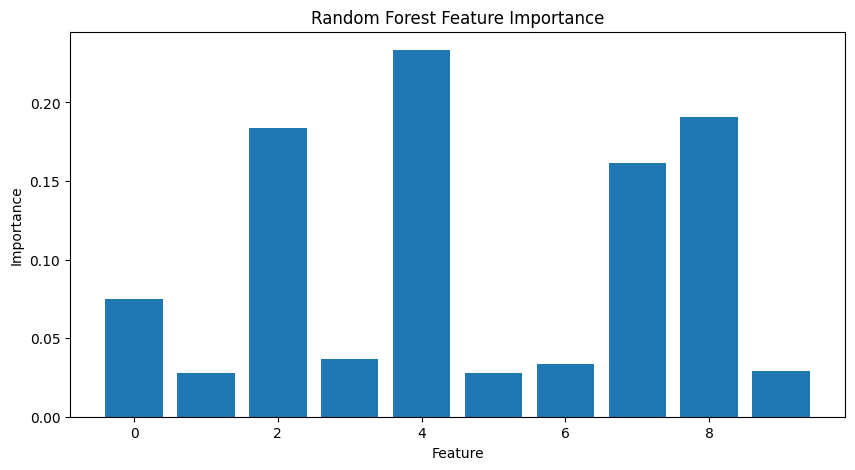

n_estimators: 10 Accuracy: 0.92
n_estimators: 50 Accuracy: 0.945
n_estimators: 100 Accuracy: 0.94
n_estimators: 200 Accuracy: 0.945
max_depth: 2 | Train: 0.83625 | Test: 0.855
max_depth: 5 | Train: 0.94375 | Test: 0.925
max_depth: 10 | Train: 0.99625 | Test: 0.945
max_depth: None | Train: 1.0 | Test: 0.94
MSE: 276.59683235393123
RMSE: 16.631200568627968
R2: 0.9342554370131045


In [ ]:
# ============================================================
# RANDOM FOREST
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
# 1. CREATE CLASSIFICATION DATA
# ============================================================

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=0,
    random_state=42
)


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 3. RANDOM FOREST CLASSIFIER
# ============================================================

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)


# ============================================================
# 4. TRAIN
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 5. PREDICT
# ============================================================

pred = model.predict(X_test)


# ============================================================
# 6. EVALUATE
# ============================================================

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, pred))


# ============================================================
# 7. PREDICT PROBABILITIES
# ============================================================

probabilities = model.predict_proba(X_test)

print(probabilities[:5])


# ============================================================
# 8. NUMBER OF TREES
# ============================================================

print("Number of trees:", len(model.estimators_))


# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

print("Feature importance:")
print(importance)


# ============================================================
# 10. FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    range(len(importance)),
    importance
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()


# ============================================================
# 11. EXPERIMENT WITH NUMBER OF TREES
# ============================================================

for n in [10, 50, 100, 200]:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    score = model.score(
        X_test,
        y_test
    )

    print(
        "n_estimators:",
        n,
        "Accuracy:",
        score
    )


# ============================================================
# 12. EXPERIMENT WITH MAX DEPTH
# ============================================================

for depth in [2, 5, 10, None]:

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_score = model.score(
        X_train,
        y_train
    )

    test_score = model.score(
        X_test,
        y_test
    )

    print(
        "max_depth:",
        depth,
        "| Train:",
        train_score,
        "| Test:",
        test_score
    )


# ============================================================
# 13. RANDOM FOREST REGRESSION
# ============================================================

X_reg, y_reg = make_regression(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    noise=10,
    random_state=42
)


# ============================================================
# 14. TRAIN / TEST SPLIT
# ============================================================

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)


# ============================================================
# 15. RANDOM FOREST REGRESSOR
# ============================================================

# Random Forest
#      ↓
# Bootstrap samples
#      ↓
# Many Decision Trees
#      ↓
# Random features at each split
#      ↓
# Voting / Averaging
#      ↓
# Reduced variance
reg_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    max_features=1.0,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42
)


# ============================================================
# 16. TRAIN
# ============================================================

reg_model.fit(
    X_reg_train,
    y_reg_train
)


# ============================================================
# 17. PREDICT
# ============================================================

reg_pred = reg_model.predict(
    X_reg_test
)


# ============================================================
# 18. EVALUATE
# ============================================================

mse = mean_squared_error(
    y_reg_test,
    reg_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_reg_test,
    reg_pred
)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


# ============================================================
# 19. IMPORTANT PARAMETERS
# ============================================================

# n_estimators
#   Number of trees in the forest.
#
#   More trees usually make the model more stable,
#   but increase training/inference cost.
#
#
# max_depth
#   Maximum depth of every tree.
#
#   Smaller → simpler trees
#   Larger → more complex trees
#
#
# max_features
#   Number of features considered when searching
#   for each split.
#
#   "sqrt" is commonly used for classification.
#
#
# min_samples_split
#   Minimum number of samples required to split
#   an internal node.
#
#
# min_samples_leaf
#   Minimum number of samples allowed in a leaf.
#
#
# bootstrap
#   Whether each tree is trained using a bootstrap
#   sample of the training data.
#
#
# max_samples
#   Number/fraction of samples used for each tree
#   when bootstrap=True.
#
#
# class_weight
#   Useful when classes are imbalanced.
#
#
# random_state
#   Makes the random process reproducible.


# ============================================================
# 20. INTERVIEW NOTES
# ============================================================

# Random Forest = Bagging + Random Feature Selection
#
# 1. Create bootstrap samples.
# 2. Train a Decision Tree on each sample.
# 3. At every split, consider a random subset of features.
# 4. Classification → majority voting.
# 5. Regression → average predictions.
#
# Why does it work?
#
# Individual trees have high variance.
# Random Forest creates diverse, less-correlated trees
# and combines them, reducing variance.
#
# Random Forest vs Decision Tree:
#
# Decision Tree → one tree → high variance
# Random Forest → many randomized trees → lower variance
#
# Random Forest vs Gradient Boosting:
#
# Random Forest:
#   Trees are mostly independent.
#   Uses bagging.
#   Reduces variance.
#   Trees can be trained in parallel.
#
# Gradient Boosting:
#   Trees are sequential.
#   Each tree corrects previous errors.
#   Uses boosting.
#   Often focuses more on reducing bias.